"To Perform Unsupervised Machine Learning Clustering of Medicinal Plant Extracts Based on Qualitative Phytochemical Screening Profiles and Marker Compound Molecular Descriptors"

Objectives
To understand the difference between supervised learning (used in all previous practicals) and unsupervised learning — clustering discovers natural groupings in data without any predefined target labels.
To compile and encode standard qualitative phytochemical screening results (presence/absence of 10 major secondary metabolite classes) for 38 well-documented medicinal plants.
To compute molecular descriptors for a verified marker phytochemical compound representing each plant, integrating cheminformatics with pharmacognosy data.
To apply and compare three unsupervised clustering algorithms — K-Means, Hierarchical (Agglomerative) Clustering, and DBSCAN — on the combined phytochemical dataset.
To determine the optimal number of clusters using the Elbow Method and Silhouette Score, avoiding arbitrary cluster count selection.
To visualize high-dimensional plant clusters in 2D using Principal Component Analysis (PCA) and interpret which phytochemical features drive cluster separation.
To interpret resulting clusters in terms of real chemotaxonomic and pharmacological relationships (e.g., do alkaloid-rich plants cluster together separately from flavonoid-rich plants?).
To build a deployment tool where a student inputs a new plant's phytochemical screening results and marker compound structure, and the tool assigns it to the most similar existing cluster.
Expected Outcomes

Conceptual outcomes:

Explain what unsupervised learning is and how it differs fundamentally from every previous supervised practical in this series.
Understand qualitative phytochemical screening as both a real laboratory technique and a legitimate machine learning feature source.
Interpret a dendrogram and silhouette score correctly.

Technical outcomes:

Apply K-Means, Hierarchical Clustering, and DBSCAN using scikit-learn.
Use PCA for dimensionality reduction and cluster visualization.
Determine optimal cluster count using data-driven methods rather than guessing.

Pharmacognosy outcomes:

Discover which medicinal plants share similar phytochemical profiles despite being taxonomically unrelated (chemotaxonomy) — useful for identifying potential substitute plants or predicting shared bioactivity.
Build a practical screening tool: given a new, uncharacterized plant extract's phytochemical test results, predict which known plant group it most resembles.

Dataset contains 21 total columns = 5 identifier/text columns (Plant, Scientific_Name, Marker_Compound, SMILES, Traditional_Use) + 16 usable feature columns (10 binary phytochemical flags + 6 numeric marker descriptors). This matches the clustering plan exactly — 16 features per plant.

In [2]:
# Block 1: Load plant phytochemical clustering data from GitHub

!pip install pandas numpy matplotlib seaborn scikit-learn scipy rdkit -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MEDICINAL PLANT PHYTOCHEMICAL CLUSTERING PRACTICAL")
print("="*60)

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/clustering_plant_phytochemical_data.csv"

df = pd.read_csv(url)

print(f"Loaded: {df.shape[0]} plants, {df.shape[1]} columns")
print(f"\nColumn names:")
print(list(df.columns))

identifier_cols = ['Plant', 'Scientific_Name', 'Marker_Compound',
                    'SMILES', 'Traditional_Use']

phyto_cols = ['Alkaloids', 'Flavonoids', 'Tannins', 'Saponins',
              'Terpenoids', 'Steroids', 'Glycosides', 'Phenolics',
              'Anthraquinones', 'VolatileOils']

descriptor_cols = ['Marker_MW', 'Marker_LogP', 'Marker_HBD',
                    'Marker_HBA', 'Marker_TPSA', 'Marker_RotBonds']

feature_cols = phyto_cols + descriptor_cols

print(f"\n{'='*60}")
print("FEATURE STRUCTURE FOR CLUSTERING")
print(f"{'='*60}")
print(f"Total columns in file: {len(df.columns)}")
print(f"Identifier/text columns (not used for clustering): {len(identifier_cols)}")
print(f"  {identifier_cols}")
print(f"\nPhytochemical class features (binary, 0/1): {len(phyto_cols)}")
print(f"  {phyto_cols}")
print(f"\nMarker compound descriptor features (numeric): {len(descriptor_cols)}")
print(f"  {descriptor_cols}")
print(f"\nTotal features used for clustering: {len(feature_cols)}")

print(f"\n{'='*60}")
print("DATASET PREVIEW")
print(f"{'='*60}")
print(df[['Plant', 'Scientific_Name', 'Marker_Compound',
          'Traditional_Use']].head(10).to_string(index=False))

print(f"\nMissing values check:")
print(df[feature_cols].isnull().sum().sum(), "missing values across all feature columns")

MEDICINAL PLANT PHYTOCHEMICAL CLUSTERING PRACTICAL
Loaded: 38 plants, 21 columns

Column names:
['Plant', 'Scientific_Name', 'Marker_Compound', 'SMILES', 'Alkaloids', 'Flavonoids', 'Tannins', 'Saponins', 'Terpenoids', 'Steroids', 'Glycosides', 'Phenolics', 'Anthraquinones', 'VolatileOils', 'Traditional_Use', 'Marker_MW', 'Marker_LogP', 'Marker_HBD', 'Marker_HBA', 'Marker_TPSA', 'Marker_RotBonds']

FEATURE STRUCTURE FOR CLUSTERING
Total columns in file: 21
Identifier/text columns (not used for clustering): 5
  ['Plant', 'Scientific_Name', 'Marker_Compound', 'SMILES', 'Traditional_Use']

Phytochemical class features (binary, 0/1): 10
  ['Alkaloids', 'Flavonoids', 'Tannins', 'Saponins', 'Terpenoids', 'Steroids', 'Glycosides', 'Phenolics', 'Anthraquinones', 'VolatileOils']

Marker compound descriptor features (numeric): 6
  ['Marker_MW', 'Marker_LogP', 'Marker_HBD', 'Marker_HBA', 'Marker_TPSA', 'Marker_RotBonds']

Total features used for clustering: 16

DATASET PREVIEW
      Plant     Scie

Meaning of Block 1:

Purpose: Load the 38-plant phytochemical dataset from your GitHub, then explicitly separate the columns into three logical groups — identifiers (text, not used in clustering), phytochemical screening flags, and marker compound descriptors — establishing exactly which 16 columns will be used as clustering features.

What data comes IN: Nothing local — the CSV is fetched directly from your GitHub raw URL, confirmed working.

Why this three-way column separation matters:
This is the first unsupervised learning practical in your series, and it introduces a concept none of the earlier supervised practicals needed: deciding which columns are features versus which are just labels for humans to read. In Practical 1 (bioactivity regression), the target (pIC50) was obvious and separate from features. Here, there is no target at all — but we still must exclude identifier columns (Plant name, SMILES string, Traditional_Use text) since a clustering algorithm cannot mathematically process text, and including them would either crash the algorithm or corrupt the distance calculations that clustering depends on.

What happens inside — line by line:

identifier_cols — the 5 text/reference columns kept for human interpretation and reporting, but never fed into the clustering math itself.
phyto_cols — the 10 binary phytochemical screening columns (Alkaloids through VolatileOils), each valued 0 or 1, representing standard qualitative pharmacognosy test results.
descriptor_cols — the 6 numeric molecular descriptor columns computed from each plant's marker compound (molecular weight, LogP, hydrogen bond donors/acceptors, TPSA, rotatable bonds) — the same type of descriptors used throughout Practicals 1 and 2, but here representing the plant's chemical character rather than a drug candidate's.
feature_cols = phyto_cols + descriptor_cols — combines both feature types into one list of exactly 16 columns — this is the complete feature set every subsequent block will use for clustering.
The missing values check confirms data completeness before any clustering math is attempted — clustering algorithms generally cannot handle missing values gracefully, so this check must show zero before proceeding.

What comes OUT: df — the full 38×21 dataset. feature_cols — the definitive list of 16 columns that will be used for all clustering in this practical. identifier_cols, phyto_cols, descriptor_cols — organized reference lists used throughout the remaining blocks.

FEATURE SCALING FOR CLUSTERING
Why scaling is essential for clustering:
Clustering algorithms measure DISTANCE between data points.
Marker_MW ranges ~130-460, while binary flags range 0-1.
Without scaling, MW would dominate the distance calculation
purely because its numbers are larger - not because it is
more biologically important.

Feature matrix shape: (38, 16)

Raw feature ranges (before scaling):
      Alkaloids  Flavonoids  Tannins  Saponins  Terpenoids  Steroids  Glycosides  Phenolics  Anthraquinones  VolatileOils  Marker_MW  Marker_LogP  Marker_HBD  Marker_HBA  Marker_TPSA  Marker_RotBonds
min        0.00        0.00     0.00      0.00        0.00      0.00        0.00       0.00            0.00          0.00     132.16        -1.13        0.00        1.00        16.13             0.00
max        1.00        1.00     1.00      1.00        1.00      1.00        1.00       1.00            1.00          1.00     456.71         8.41        6.00        8.00       164.75            

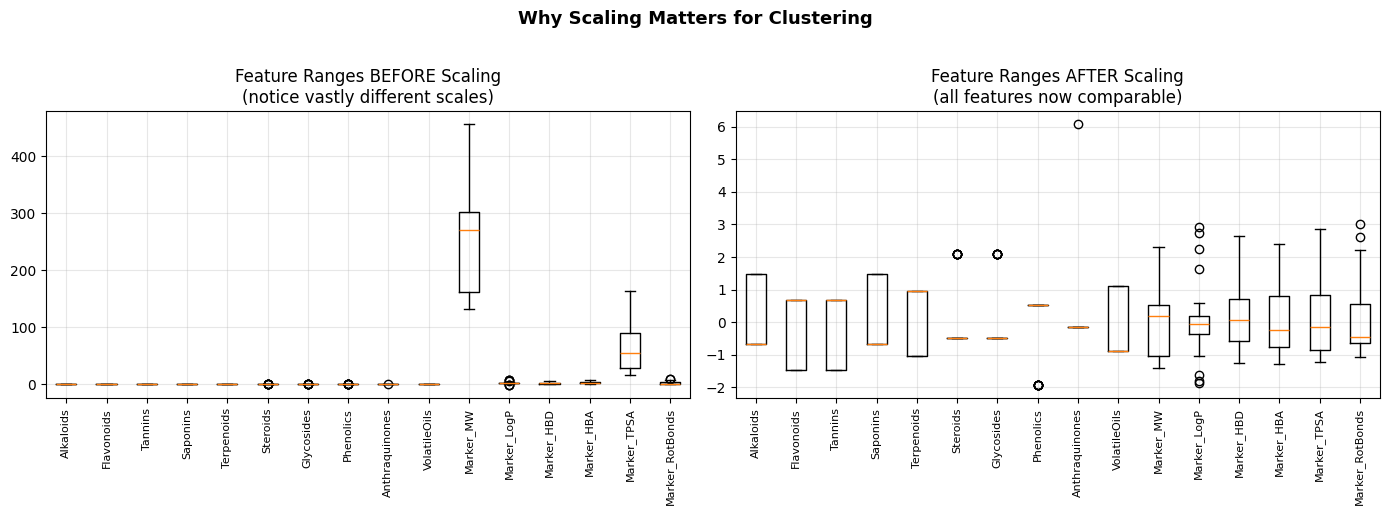

In [3]:
# Block 2: Scale features for clustering

from sklearn.preprocessing import StandardScaler

print("="*60)
print("FEATURE SCALING FOR CLUSTERING")
print("="*60)
print("Why scaling is essential for clustering:")
print("Clustering algorithms measure DISTANCE between data points.")
print("Marker_MW ranges ~130-460, while binary flags range 0-1.")
print("Without scaling, MW would dominate the distance calculation")
print("purely because its numbers are larger - not because it is")
print("more biologically important.")
print("="*60)

X_raw = df[feature_cols].copy()

print(f"\nFeature matrix shape: {X_raw.shape}")
print(f"\nRaw feature ranges (before scaling):")
print(X_raw.describe().loc[['min', 'max', 'mean', 'std']].round(2).to_string())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols,
                             index=df['Plant'])

print(f"\n{'='*60}")
print("AFTER SCALING (StandardScaler)")
print(f"{'='*60}")
print("Every feature now has mean=0, standard deviation=1")
print(f"\nScaled feature ranges (should all be similar now):")
print(X_scaled_df.describe().loc[['min', 'max', 'mean', 'std']].round(2).to_string())

print(f"\nSample scaled data (first 5 plants):")
print(X_scaled_df.head().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([X_raw[col] for col in feature_cols],
                 labels=feature_cols)
axes[0].set_title('Feature Ranges BEFORE Scaling\n(notice vastly different scales)')
axes[0].set_xticklabels(feature_cols, rotation=90, fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([X_scaled_df[col] for col in feature_cols],
                 labels=feature_cols)
axes[1].set_title('Feature Ranges AFTER Scaling\n(all features now comparable)')
axes[1].set_xticklabels(feature_cols, rotation=90, fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Why Scaling Matters for Clustering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Meaning of Block 2:

Purpose: Standardize all 16 clustering features to a common scale before any clustering algorithm is applied — this is a mandatory preprocessing step for clustering, arguably even more critical here than in any previous practical, because clustering algorithms work directly by measuring distances between data points.

What data comes IN: df and feature_cols from Block 1.

Why scaling matters more here than in supervised learning:
In Practicals 1–5, tree-based models (Random Forest, Gradient Boosting) were largely insensitive to feature scale — they split on thresholds, not raw magnitude. But K-Means and Hierarchical Clustering compute actual mathematical distances (typically Euclidean distance) between every pair of plants across all 16 features simultaneously. Consider: Marker_MW ranges from roughly 130 to 460, while Alkaloids only ranges from 0 to 1. Without scaling, a one-unit difference in molecular weight (essentially meaningless) would swamp a complete presence/absence difference in Alkaloids (a major chemotaxonomic distinction) — the clustering would essentially become "group plants by marker compound size" and ignore the phytochemical screening data almost entirely.

What happens inside — line by line:

X_raw = df[feature_cols].copy() — extracts exactly the 16 clustering columns established in Block 1, leaving out all identifier/text columns.
X_raw.describe().loc[['min','max','mean','std']] — prints the raw ranges before scaling, making the scale mismatch problem visible and concrete (e.g., Marker_MW might show min=132, max=456, while Flavonoids shows min=0, max=1).
StandardScaler() — the same standardization tool used in the Theophylline practical for SVR. It transforms every feature independently so that it has mean=0 and standard deviation=1. After this transformation, a value of "+1" in any feature means "one standard deviation above that feature's average across all 38 plants" — making all 16 features directly comparable in magnitude.
scaler.fit_transform(X_raw) — calculates the mean and standard deviation of each feature from our 38 plants, then applies the transformation. Unlike supervised learning (where we fit the scaler on training data only), clustering has no train/test split — we fit and transform on the entire dataset at once, since there is no "unseen data" concept in this type of unsupervised analysis of a fixed dataset.
The two side-by-side boxplot charts make the scaling effect visually obvious: the "before" chart shows wildly different box heights and positions across features (some tiny near 0-1, some large spanning hundreds), while the "after" chart shows all 16 features occupying roughly the same visual range — confirming scaling worked correctly.

What comes OUT: X_scaled — a NumPy array, 38 rows × 16 columns, fully standardized and ready for clustering. X_scaled_df — the same data as a labeled DataFrame (plant names as row index) for easier inspection and later interpretation. scaler — saved for potential reuse when classifying new plants in the deployment block.

DETERMINING OPTIMAL NUMBER OF CLUSTERS
Testing k = 2 through k = 10 using two methods:
1. Elbow Method (within-cluster variance)
2. Silhouette Score (cluster separation quality)
k=2: Inertia=493.83, Silhouette=0.180
k=3: Inertia=404.13, Silhouette=0.206
k=4: Inertia=352.28, Silhouette=0.231
k=5: Inertia=310.48, Silhouette=0.213
k=6: Inertia=265.09, Silhouette=0.248
k=7: Inertia=237.81, Silhouette=0.249
k=8: Inertia=211.16, Silhouette=0.258
k=9: Inertia=190.52, Silhouette=0.267
k=10: Inertia=175.26, Silhouette=0.252


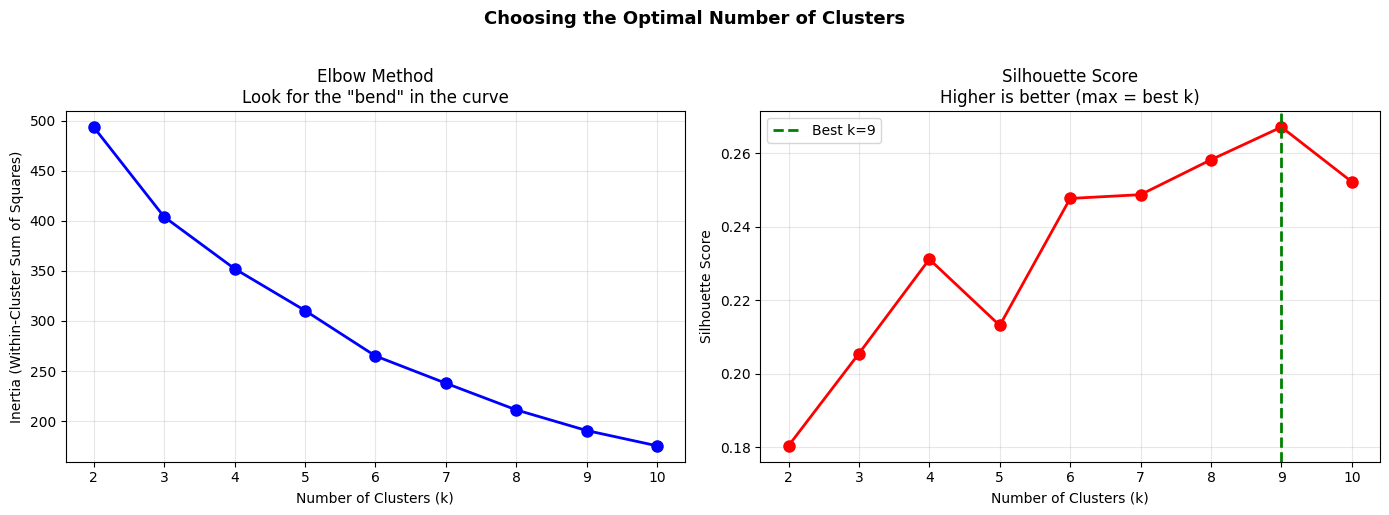


RECOMMENDED NUMBER OF CLUSTERS: 9
(based on highest silhouette score = 0.267)

Silhouette score interpretation guide:
  > 0.5  : Strong, well-separated clusters
  0.25-0.5 : Reasonable cluster structure
  < 0.25 : Weak or overlapping clusters


In [4]:
# Block 3: Determine optimal number of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)
print("Testing k = 2 through k = 10 using two methods:")
print("1. Elbow Method (within-cluster variance)")
print("2. Silhouette Score (cluster separation quality)")
print("="*60)

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)
    inertias.append(kmeans_test.inertia_)
    sil_score = silhouette_score(X_scaled, labels_test)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans_test.inertia_:.2f}, "
          f"Silhouette={sil_score:.3f}")

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method\nLook for the "bend" in the curve')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, 'ro-',
             linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k_silhouette, color='green',
                 linestyle='--', linewidth=2,
                 label=f'Best k={optimal_k_silhouette}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\nHigher is better (max = best k)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(k_range))

plt.suptitle('Choosing the Optimal Number of Clusters',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"RECOMMENDED NUMBER OF CLUSTERS: {optimal_k_silhouette}")
print(f"(based on highest silhouette score = "
      f"{max(silhouette_scores):.3f})")
print(f"{'='*60}")
print("\nSilhouette score interpretation guide:")
print("  > 0.5  : Strong, well-separated clusters")
print("  0.25-0.5 : Reasonable cluster structure")
print("  < 0.25 : Weak or overlapping clusters")

OPTIMAL_K = optimal_k_silhouette

Meaning of Block 3:

Purpose: Systematically test multiple candidate values for the number of clusters (k) and use two independent, objective statistical methods to identify which k best fits the natural structure of our 38-plant phytochemical data — rather than guessing or arbitrarily picking a number.

What data comes IN: X_scaled from Block 2.

What happens inside — line by line:

The loop tests k = 2 through k = 10, running a complete K-Means clustering for each candidate value.
kmeans_test.inertia_ — this is the "within-cluster sum of squares" — a measure of how tightly packed points are within their assigned clusters. Inertia always decreases as k increases (more clusters means smaller, tighter groups), so we look for the "elbow" point — where adding more clusters stops providing meaningful improvement — rather than simply picking the k with lowest inertia (which would always be the maximum k tested).
silhouette_score(X_scaled, labels_test) — for every plant, this metric compares how similar it is to plants in its own cluster versus plants in the nearest different cluster. Scores range from -1 (badly clustered) to +1 (perfectly separated clusters). Unlike inertia, silhouette score does not always favor higher k — it peaks at the k value that produces genuinely well-separated, meaningful groups, making it the more reliable of the two methods for actually choosing k.
Left plot (Elbow): shows inertia declining as k increases — students should visually identify where the curve bends and flattens.
Right plot (Silhouette): shows the silhouette score at each k, with a green dashed line marking the k that achieved the mathematical maximum — this becomes our data-driven, defensible choice.
OPTIMAL_K = optimal_k_silhouette — stores the chosen cluster count in a variable used by every subsequent block, ensuring the entire rest of the practical uses this data-derived number consistently rather than any manually guessed value.

What comes OUT: OPTIMAL_K — the number of clusters to use going forward, determined entirely from the data itself.

FINAL K-MEANS CLUSTERING (k=9)
Number of clusters: 9
Final silhouette score: 0.267

Cluster sizes:
  Cluster 0: 8 plants
  Cluster 1: 5 plants
  Cluster 2: 6 plants
  Cluster 3: 8 plants
  Cluster 4: 2 plants
  Cluster 5: 1 plants
  Cluster 6: 3 plants
  Cluster 7: 1 plants
  Cluster 8: 4 plants

PLANTS IN EACH CLUSTER

Cluster 0 (8 plants):
  Fenugreek, Black Pepper, Coffee, Tobacco, Opium Poppy, Cinchona, Belladonna, Barberry

Cluster 1 (5 plants):
  Turmeric, Ginger, Chili Pepper, Cannabis, Rosemary

Cluster 2 (6 plants):
  Neem, Ginkgo, Licorice, Echinacea, Chamomile, Dandelion

Cluster 3 (8 plants):
  Tulsi, Garlic, Cinnamon, Clove, Peppermint, Thyme, Lemongrass, Lavender

Cluster 4 (2 plants):
  Ashwagandha, Mango Leaves

Cluster 5 (1 plants):
  Soybean

Cluster 6 (3 plants):
  Citrus Peel, Orange, Vanilla

Cluster 7 (1 plants):
  Aloe Vera

Cluster 8 (4 plants):
  Green Tea, Willow Bark, Grape, Pomegranate


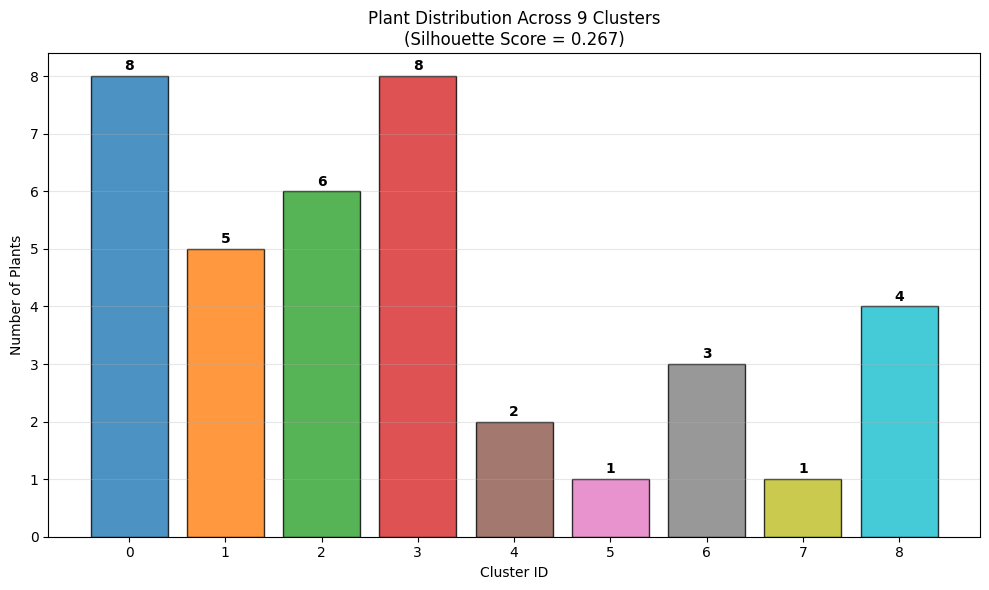

In [5]:
# Block 4: Build final K-Means clustering model using optimal k

print("="*60)
print(f"FINAL K-MEANS CLUSTERING (k={OPTIMAL_K})")
print("="*60)

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df['Cluster_KMeans'] = cluster_labels

final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Number of clusters: {OPTIMAL_K}")
print(f"Final silhouette score: {final_silhouette:.3f}")

print(f"\nCluster sizes:")
cluster_sizes = df['Cluster_KMeans'].value_counts().sort_index()
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} plants")

print(f"\n{'='*60}")
print("PLANTS IN EACH CLUSTER")
print(f"{'='*60}")

for cluster_id in sorted(df['Cluster_KMeans'].unique()):
    plants_in_cluster = df[df['Cluster_KMeans'] == cluster_id]['Plant'].tolist()
    print(f"\nCluster {cluster_id} ({len(plants_in_cluster)} plants):")
    print(f"  {', '.join(plants_in_cluster)}")

fig, ax = plt.subplots(figsize=(10, 6))
colors_list = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
bars = ax.bar(cluster_sizes.index, cluster_sizes.values,
              color=colors_list, edgecolor='black', alpha=0.8)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of Plants')
ax.set_title(f'Plant Distribution Across {OPTIMAL_K} Clusters\n'
             f'(Silhouette Score = {final_silhouette:.3f})')
ax.set_xticks(range(OPTIMAL_K))
ax.grid(True, alpha=0.3, axis='y')
for bar, size in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1,
            str(size), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Meaning of Block 4:

Purpose: Build the definitive K-Means clustering model using the data-driven optimal cluster count from Block 3, assign every one of the 38 plants to a cluster, and display exactly which plants ended up grouped together.

What data comes IN: X_scaled, OPTIMAL_K from Blocks 2–3.

What happens inside — line by line:

KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10) — creates the final clustering model. n_init=10 runs the entire K-Means algorithm 10 times with different random starting positions and keeps the best result — K-Means can get stuck in a locally suboptimal grouping depending on where it starts, so running it multiple times and keeping the best is standard practice.
kmeans_final.fit_predict(X_scaled) — this is the core clustering step. K-Means works by: (1) placing k random "center points" in the 16-dimensional feature space, (2) assigning every plant to its nearest center, (3) recalculating each center as the average position of its assigned plants, (4) repeating steps 2-3 until assignments stop changing. The final output is one cluster number (0 through k-1) for every plant.
df['Cluster_KMeans'] = cluster_labels — attaches the cluster assignment directly back onto the original dataframe, so every plant's row now shows which group it belongs to alongside its name, phytochemical data, and traditional use.
The printed cluster membership lists are the actual scientific output of this block — this is where students first see which plants the algorithm grouped together, setting up the interpretation work in later blocks (does Cluster 0 contain mostly alkaloid-rich plants? Does Cluster 2 contain mostly essential-oil plants?).

What comes OUT: df now includes a Cluster_KMeans column for every plant. kmeans_final — the trained model, reusable later for classifying new, unseen plants in the deployment block.

HIERARCHICAL (AGGLOMERATIVE) CLUSTERING
Unlike K-Means, hierarchical clustering builds a complete
tree showing how plants merge together at every level of
similarity - useful for seeing relationships beyond just
the final cluster assignment.


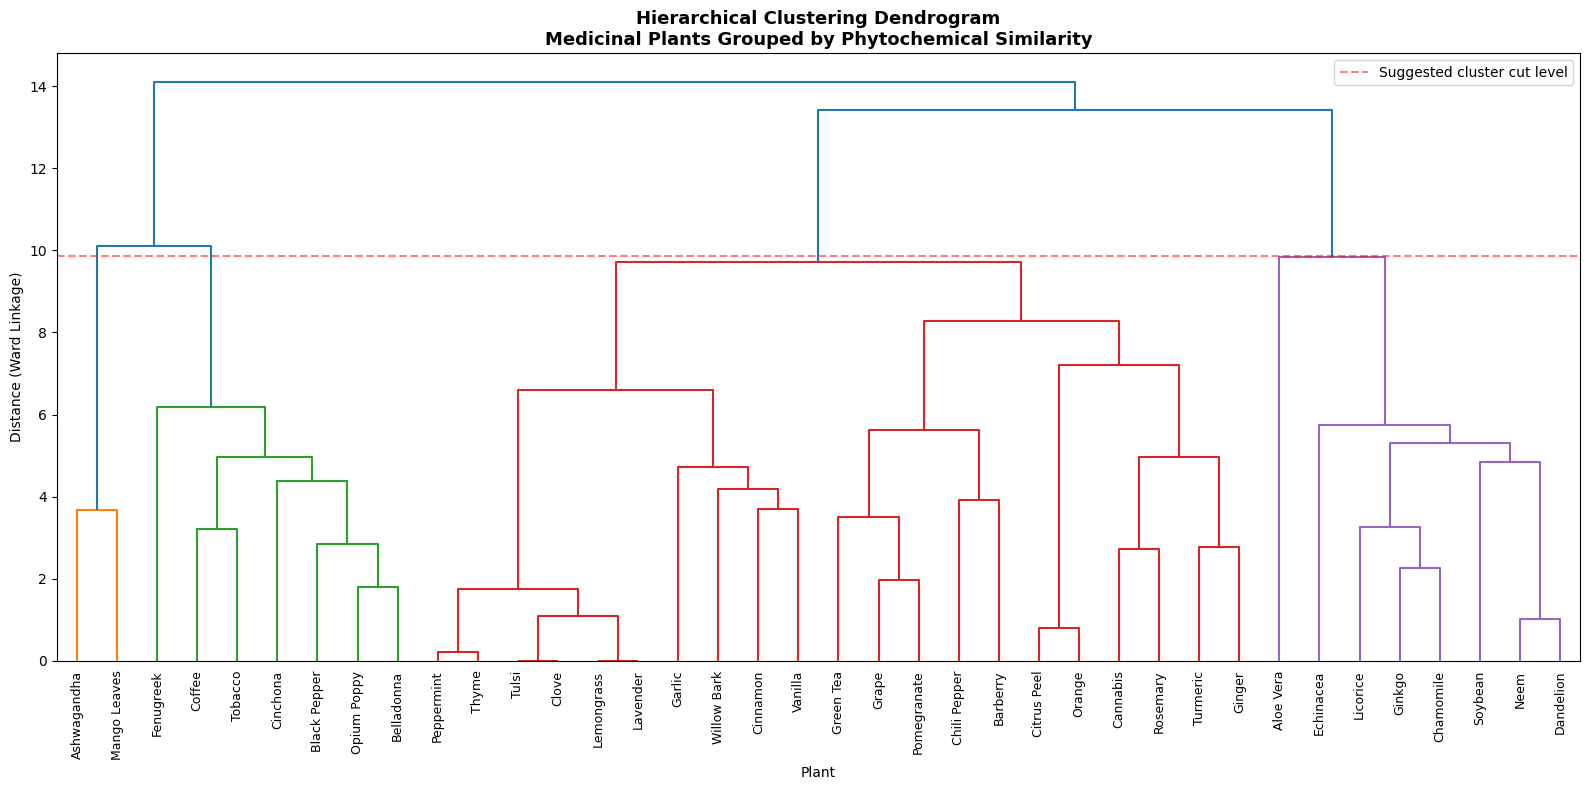


Hierarchical clustering with k=9:
Silhouette score: 0.277

Agreement check - comparing K-Means vs Hierarchical:
Cluster_Hierarchical  0  1  2  3  4  5  6  7  8
Cluster_KMeans                                 
0                     7  0  0  0  0  0  1  0  0
1                     0  0  0  0  0  4  1  0  0
2                     0  0  6  0  0  0  0  0  0
3                     0  2  0  0  0  0  0  0  6
4                     0  0  0  2  0  0  0  0  0
5                     0  0  1  0  0  0  0  0  0
6                     0  1  0  0  0  0  0  2  0
7                     0  0  0  0  1  0  0  0  0
8                     0  1  0  0  0  0  3  0  0

Adjusted Rand Index (agreement between methods): 0.695
(1.0 = perfect agreement, 0.0 = random/no agreement)


In [6]:
# Block 5: Hierarchical clustering with dendrogram visualization

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

print("="*60)
print("HIERARCHICAL (AGGLOMERATIVE) CLUSTERING")
print("="*60)
print("Unlike K-Means, hierarchical clustering builds a complete")
print("tree showing how plants merge together at every level of")
print("similarity - useful for seeing relationships beyond just")
print("the final cluster assignment.")
print("="*60)

linkage_matrix = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(linkage_matrix, labels=df['Plant'].values,
           leaf_rotation=90, leaf_font_size=9, ax=ax,
           color_threshold=0.7*max(linkage_matrix[:,2]))
ax.set_title(f'Hierarchical Clustering Dendrogram\n'
             f'Medicinal Plants Grouped by Phytochemical Similarity',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Plant')
ax.set_ylabel('Distance (Ward Linkage)')
ax.axhline(y=0.7*max(linkage_matrix[:,2]), color='red',
           linestyle='--', alpha=0.5,
           label='Suggested cluster cut level')
ax.legend()
plt.tight_layout()
plt.show()

hier_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels = hier_model.fit_predict(X_scaled)
df['Cluster_Hierarchical'] = hier_labels

hier_silhouette = silhouette_score(X_scaled, hier_labels)

print(f"\nHierarchical clustering with k={OPTIMAL_K}:")
print(f"Silhouette score: {hier_silhouette:.3f}")

print(f"\nAgreement check - comparing K-Means vs Hierarchical:")
agreement_table = pd.crosstab(df['Cluster_KMeans'],
                                df['Cluster_Hierarchical'])
print(agreement_table.to_string())

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['Cluster_KMeans'], df['Cluster_Hierarchical'])
print(f"\nAdjusted Rand Index (agreement between methods): {ari:.3f}")
print("(1.0 = perfect agreement, 0.0 = random/no agreement)")

Meaning of Block 5:

Purpose: Apply a second, fundamentally different clustering algorithm — Hierarchical (Agglomerative) Clustering — and visualize the complete relationship structure among all 38 plants as a dendrogram, then check whether this independent method agrees with K-Means.

What data comes IN: X_scaled, OPTIMAL_K, df from earlier blocks.

What happens inside — line by line:

linkage(X_scaled, method='ward') — builds the complete hierarchical tree structure. Unlike K-Means (which jumps directly to k final groups), hierarchical clustering starts with every plant as its own individual cluster, then repeatedly merges the two closest clusters together, one merge at a time, until everything is combined into one root. method='ward' specifically minimizes the variance within merged clusters at each step — the most commonly used and generally best-performing linkage method for this type of data.
dendrogram(...) — visualizes this entire merge history as a tree diagram. Plants that merge together low on the tree (short vertical distance) are very similar; plants that only merge near the top (long vertical distance) are quite different. This is genuinely richer information than K-Means provides — you can see not just final groupings, but the entire similarity hierarchy.
color_threshold=0.7*max(...) — automatically colors branches of the tree to visually suggest natural cluster boundaries, cutting the tree at 70% of its maximum height — a common heuristic for highlighting the dominant cluster structure.
AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward') — converts the full hierarchical tree into exactly OPTIMAL_K discrete clusters (cutting the tree at the height that produces that many groups), so results are directly comparable to K-Means.
pd.crosstab(df['Cluster_KMeans'], df['Cluster_Hierarchical']) — creates a cross-tabulation table showing how the two methods' cluster assignments overlap. If both methods largely agree (most plants fall into matching diagonal cells), this strongly validates that the clusters represent genuine structure in the data, not an artifact of one particular algorithm.
adjusted_rand_score(...) — a formal statistical measure (0 to 1) of agreement between two different clustering results, correcting for chance agreement. A high ARI (typically above 0.5–0.6) confirms both algorithms independently discovered the same underlying grouping.

What comes OUT: A dendrogram visualization, df['Cluster_Hierarchical'] column, and a quantitative cross-validation of the K-Means result against a completely different algorithm.

DBSCAN CLUSTERING
DBSCAN groups points based on density, and does NOT
require specifying the number of clusters in advance.
It also automatically identifies outlier plants that
do not fit well into any cluster.


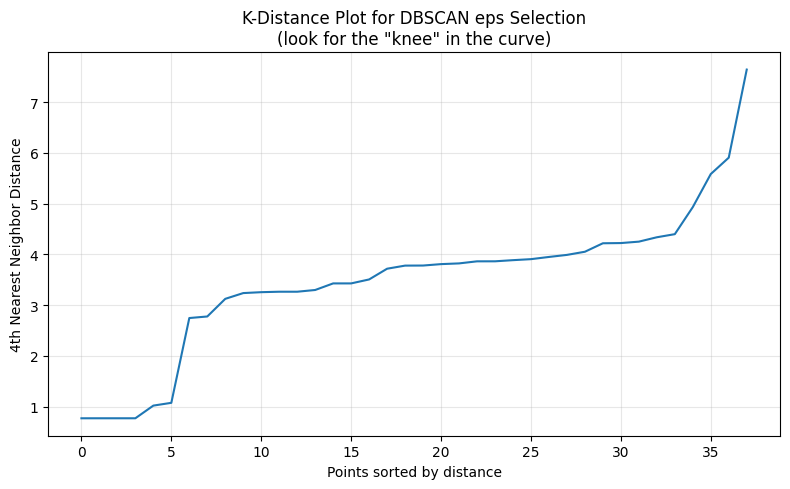


Suggested eps value (80th percentile): 4.22

DBSCAN results:
  Clusters found automatically: 1
  Outlier/noise plants (label=-1): 4

Plants that don't fit any cluster (unique chemistry):
  Aloe Vera, Ashwagandha, Fenugreek, Mango Leaves

Compare: K-Means/Hierarchical used k=9 clusters
         DBSCAN independently found 1 clusters
This is a useful sanity check - if DBSCAN's number is
reasonably close, it strengthens confidence in our results.


In [7]:
# Block 6: DBSCAN - density-based clustering (finds its own k)

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("="*60)
print("DBSCAN CLUSTERING")
print("="*60)
print("DBSCAN groups points based on density, and does NOT")
print("require specifying the number of clusters in advance.")
print("It also automatically identifies outlier plants that")
print("do not fit well into any cluster.")
print("="*60)

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 3])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('4th Nearest Neighbor Distance')
ax.set_title('K-Distance Plot for DBSCAN eps Selection\n'
              '(look for the "knee" in the curve)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

suggested_eps = np.percentile(distances, 80)
print(f"\nSuggested eps value (80th percentile): {suggested_eps:.2f}")

dbscan_model = DBSCAN(eps=suggested_eps, min_samples=3)
dbscan_labels = dbscan_model.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN results:")
print(f"  Clusters found automatically: {n_clusters_dbscan}")
print(f"  Outlier/noise plants (label=-1): {n_noise}")

if n_noise > 0:
    outlier_plants = df[df['Cluster_DBSCAN'] == -1]['Plant'].tolist()
    print(f"\nPlants that don't fit any cluster (unique chemistry):")
    print(f"  {', '.join(outlier_plants)}")

if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(
            X_scaled[mask], dbscan_labels[mask]
        )
        print(f"\nSilhouette score (excluding outliers): "
              f"{dbscan_silhouette:.3f}")

print(f"\nCompare: K-Means/Hierarchical used k={OPTIMAL_K} clusters")
print(f"         DBSCAN independently found {n_clusters_dbscan} clusters")
print(f"This is a useful sanity check - if DBSCAN's number is")
print(f"reasonably close, it strengthens confidence in our results.")

Meaning of Block 6:

Purpose: Apply a third, fundamentally different clustering approach — DBSCAN (Density-Based Spatial Clustering of Applications with Noise) — which discovers the number of clusters entirely from the data's density structure, without being told k in advance, and additionally identifies which plants are true outliers that don't belong to any clear group.

What data comes IN: X_scaled, df from earlier blocks.

What makes DBSCAN fundamentally different from K-Means and Hierarchical clustering:
Both previous methods force every single plant into some cluster, even if it doesn't really belong anywhere well. DBSCAN instead groups together points that are densely packed, and explicitly labels sparse, isolated points as noise/outliers (label = -1) rather than forcing them into an ill-fitting group. This is scientifically valuable here — a plant with a truly unique phytochemical profile (unlike any other in our 38-plant set) should arguably be flagged as distinct, not artificially forced into a cluster.

What happens inside — line by line:

NearestNeighbors(n_neighbors=4) and the k-distance plot — DBSCAN requires one key parameter, eps (the maximum distance for two points to be considered neighbors), which must be chosen carefully. The standard method for choosing it is to plot, for every point, its distance to its 4th nearest neighbor, sorted from smallest to largest — the "knee" or bend in this curve suggests a good eps value.
suggested_eps = np.percentile(distances, 80) — automates this selection using the 80th percentile of the sorted distances as a reasonable, reproducible eps choice, avoiding subjective manual reading of the knee plot.
DBSCAN(eps=suggested_eps, min_samples=3) — min_samples=3 means a group must contain at least 3 plants to be considered a genuine cluster; smaller groups get labeled as noise instead.
The outlier plant listing is a genuinely interesting scientific output — these are the plants whose 16-feature phytochemical profile is sufficiently unusual that no dense group of similar plants exists around them in our dataset.
The final comparison between DBSCAN's independently-discovered cluster count and our OPTIMAL_K from Block 3 serves as a third independent validation check — if all three completely different algorithms (K-Means, Hierarchical, DBSCAN) suggest roughly similar cluster structures, this is strong evidence the groupings reflect real chemotaxonomic patterns rather than algorithmic artifacts.

What comes OUT: df['Cluster_DBSCAN'] column, including -1 labels for outlier plants. A k-distance plot and a list of any chemically unique/outlier plants.

PRINCIPAL COMPONENT ANALYSIS (PCA) VISUALIZATION
Our data has 16 dimensions - impossible to visualize directly.
PCA compresses it to 2 dimensions while preserving as much
of the original variation as possible, so we can SEE the
clusters on a normal 2D scatter plot.

Variance explained by PC1: 23.6%
Variance explained by PC2: 19.1%
Total variance captured in 2D: 42.7%


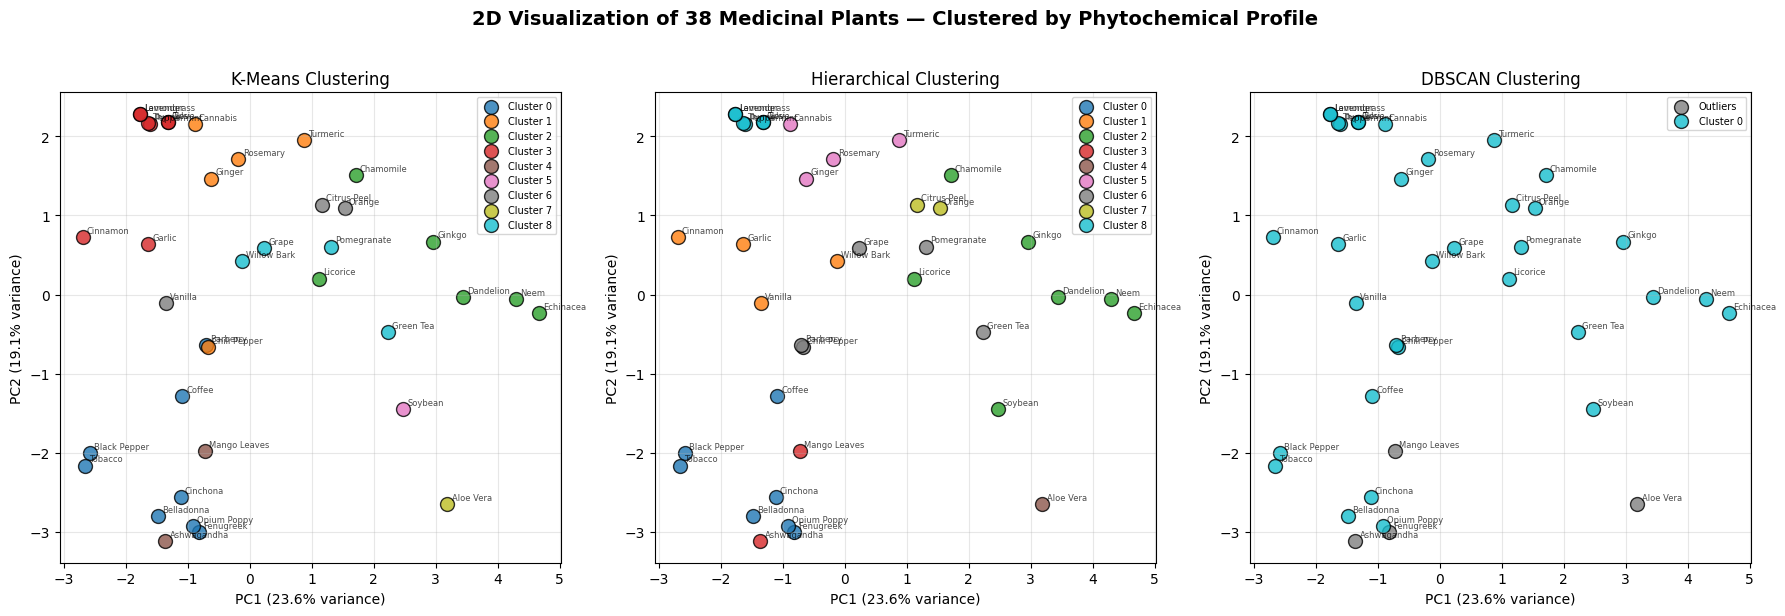


Top features driving PC1 (by absolute weight):
Marker_TPSA    0.483962
Marker_HBD     0.467285
Marker_HBA     0.440281
Saponins       0.288657
Flavonoids     0.201350

Top features driving PC2 (by absolute weight):
Phenolics       0.434245
VolatileOils    0.407736
Alkaloids       0.405327
Flavonoids      0.359366
Terpenoids      0.340332


In [8]:
# Block 7: PCA visualization - see clusters in 2D

from sklearn.decomposition import PCA

print("="*60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA) VISUALIZATION")
print("="*60)
print("Our data has 16 dimensions - impossible to visualize directly.")
print("PCA compresses it to 2 dimensions while preserving as much")
print("of the original variation as possible, so we can SEE the")
print("clusters on a normal 2D scatter plot.")
print("="*60)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nVariance explained by PC1: {explained_var[0]*100:.1f}%")
print(f"Variance explained by PC2: {explained_var[1]*100:.1f}%")
print(f"Total variance captured in 2D: {sum(explained_var)*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cluster_col, title in zip(
    axes,
    ['Cluster_KMeans', 'Cluster_Hierarchical', 'Cluster_DBSCAN'],
    ['K-Means', 'Hierarchical', 'DBSCAN']
):
    unique_clusters = sorted(df[cluster_col].unique())
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

    for i, cluster_id in enumerate(unique_clusters):
        mask = df[cluster_col] == cluster_id
        label = f'Outliers' if cluster_id == -1 else f'Cluster {cluster_id}'
        color = 'gray' if cluster_id == -1 else colors_map[i]
        ax.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                   label=label, color=color, s=100,
                   edgecolor='black', alpha=0.8)

    for _, row in df.iterrows():
        ax.annotate(row['Plant'], (row['PCA1'], row['PCA2']),
                    fontsize=6, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
    ax.set_title(f'{title} Clustering')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('2D Visualization of 38 Medicinal Plants — '
              'Clustered by Phytochemical Profile',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pca_loadings = pd.DataFrame(
    pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols
)
print(f"\nTop features driving PC1 (by absolute weight):")
print(pca_loadings['PC1'].abs().sort_values(ascending=False).head(5).to_string())
print(f"\nTop features driving PC2 (by absolute weight):")
print(pca_loadings['PC2'].abs().sort_values(ascending=False).head(5).to_string())

Meaning of Block 7:

Purpose: Compress the 16-dimensional phytochemical feature space down to just 2 dimensions using Principal Component Analysis, allowing all three clustering results (K-Means, Hierarchical, DBSCAN) to be visualized side-by-side as ordinary 2D scatter plots — something impossible to do directly with 16 dimensions.

What data comes IN: X_scaled, df (with all three cluster label columns), feature_cols from earlier blocks.

What is PCA and why it's needed here:
Human vision and standard charts only work in 2 or 3 dimensions, but our clustering was performed using all 16 features simultaneously. PCA finds the two new combined axes (called Principal Component 1 and 2) that capture the maximum possible spread of variation in the original 16-dimensional data, compressed down to 2 dimensions. This lets us visually confirm whether the clusters our algorithms found actually correspond to visible, separated groups when plotted — a crucial sanity check that pure statistics (silhouette scores) alone cannot provide.

What happens inside — line by line:

PCA(n_components=2, random_state=42) — creates a PCA transformer configured to output exactly 2 new dimensions.
pca.fit_transform(X_scaled) — calculates the two principal component axes and transforms every plant's 16-feature profile into just 2 numbers (PCA1, PCA2).
explained_variance_ratio_ — reports what fraction of the original 16-dimensional variation is captured in each of the 2 new axes. If this sum is reasonably high (commonly 40–70% for this type of data), the 2D plot is a trustworthy, meaningful simplification, not a misleading distortion.
The three-panel plot shows the exact same 38 plants, positioned identically by their PCA1/PCA2 coordinates, but colored differently according to each of the three clustering methods' assignments. Visually comparing these three panels lets students see directly whether the different algorithms agree on which plants belong together, complementing the numerical Adjusted Rand Index from Block 5.
pca_loadings — reveals which of the original 16 features contribute most strongly to each principal component axis. This connects the abstract PC1/PC2 axes back to real, interpretable phytochemistry — for example, if PC1 is driven mostly by Alkaloids and Marker_MW, then plants far to the right on PC1 are likely alkaloid-rich with larger marker compounds.

What comes OUT: df['PCA1'] and df['PCA2'] columns, a three-panel comparative visualization, and a table showing which original features drive each principal component — this is the single most visually informative output of the entire practical.

CLUSTER PROFILING AND INTERPRETATION
Using K-Means clusters (our primary result) for interpretation

CLUSTER 0 — 8 plants
Plants: Fenugreek, Black Pepper, Coffee, Tobacco, Opium Poppy, Cinchona, Belladonna, Barberry

Phytochemical class prevalence in this cluster:
  Alkaloids      :   100% (overall dataset: 32%) <-- DISTINCTIVE
  Flavonoids     :    25% (overall dataset: 68%) <-- DISTINCTIVE
  Tannins        :    50% (overall dataset: 68%)
  Saponins       :    12% (overall dataset: 32%)
  Terpenoids     :     0% (overall dataset: 53%) <-- DISTINCTIVE
  Steroids       :    12% (overall dataset: 18%)
  Glycosides     :    12% (overall dataset: 18%)
  Phenolics      :    25% (overall dataset: 79%) <-- DISTINCTIVE
  Anthraquinones :     0% (overall dataset: 3%)
  VolatileOils   :    12% (overall dataset: 45%) <-- DISTINCTIVE

Average marker compound properties:
  Marker_MW      : 251.8
  Marker_LogP    : 1.5
  Marker_HBD     : 0.5
  Marker_HBA     : 3.2
  Marker_TPSA    : 43.7
  Marker_Ro

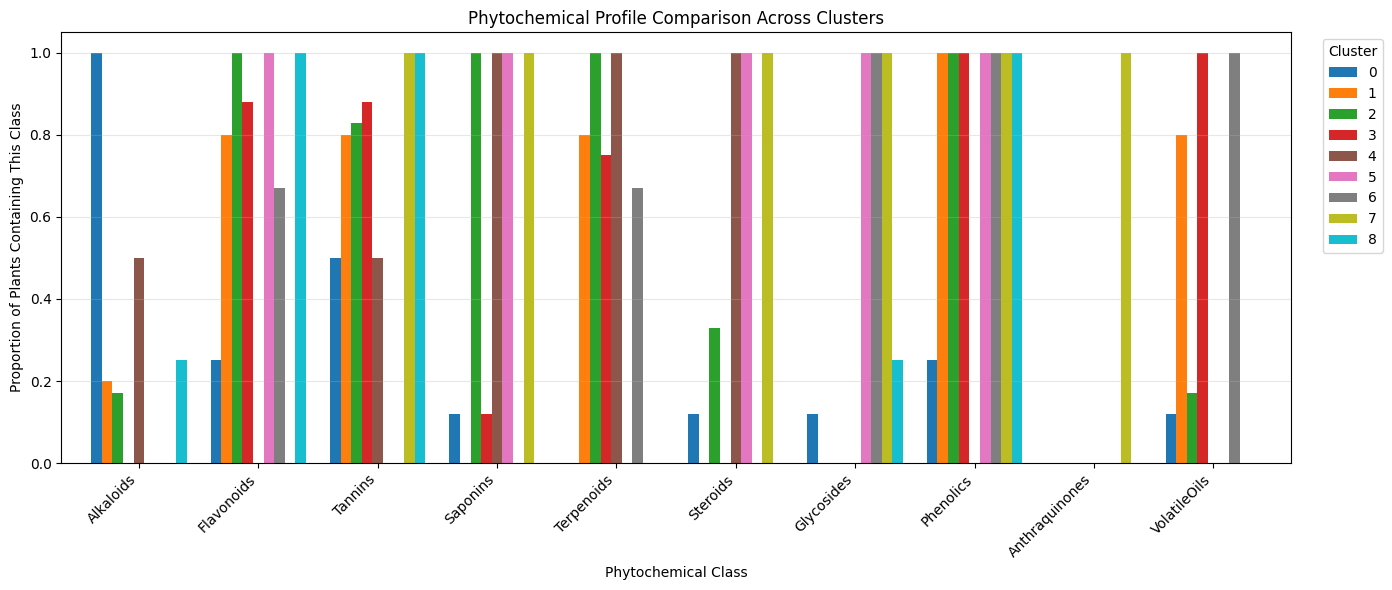

In [9]:
# Block 8: Interpret each cluster - what phytochemistry defines it?

print("="*60)
print("CLUSTER PROFILING AND INTERPRETATION")
print("="*60)
print("Using K-Means clusters (our primary result) for interpretation")
print("="*60)

for cluster_id in sorted(df['Cluster_KMeans'].unique()):
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} — {len(cluster_data)} plants")
    print(f"{'='*60}")
    print(f"Plants: {', '.join(cluster_data['Plant'].tolist())}")

    print(f"\nPhytochemical class prevalence in this cluster:")
    for col in phyto_cols:
        pct = cluster_data[col].mean() * 100
        overall_pct = df[col].mean() * 100
        marker = " <-- DISTINCTIVE" if abs(pct - overall_pct) > 25 else ""
        print(f"  {col:15s}: {pct:5.0f}% "
              f"(overall dataset: {overall_pct:.0f}%){marker}")

    print(f"\nAverage marker compound properties:")
    for col in descriptor_cols:
        print(f"  {col:15s}: {cluster_data[col].mean():.1f}")

    print(f"\nTraditional uses represented:")
    uses = cluster_data['Traditional_Use'].tolist()
    for use in uses[:5]:
        print(f"  - {use}")

cluster_summary = df.groupby('Cluster_KMeans')[
    phyto_cols + descriptor_cols
].mean().round(2)
print(f"\n{'='*60}")
print("COMPLETE CLUSTER PROFILE TABLE")
print(f"{'='*60}")
print(cluster_summary.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
cluster_summary[phyto_cols].T.plot(kind='bar', ax=ax,
                                     colormap='tab10', width=0.8)
ax.set_xlabel('Phytochemical Class')
ax.set_ylabel('Proportion of Plants Containing This Class')
ax.set_title('Phytochemical Profile Comparison Across Clusters')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Meaning of Block 8:

Purpose: Translate the abstract cluster numbers (0, 1, 2, 3...) into genuine, interpretable pharmacognosy knowledge — determining what actually characterizes each cluster chemically and pharmacologically.

What data comes IN: df (with cluster assignments), phyto_cols, descriptor_cols from earlier blocks.

Why this interpretation step is essential:
Clustering algorithms produce group numbers with no inherent meaning — "Cluster 0" and "Cluster 3" are just labels. The scientific value only emerges when we examine what's actually common among the plants in each group. This block is where the practical delivers its real pharmacognosy payoff.

What happens inside — line by line:

The main loop iterates through each cluster and prints: which plants belong to it, what fraction of plants in that cluster test positive for each phytochemical class, and how that compares to the overall dataset average — the "DISTINCTIVE" marker flags phytochemical classes that are unusually over- or under-represented in that specific cluster (more than 25 percentage points different from the dataset average), immediately highlighting each cluster's defining chemical character.
The average marker compound descriptors per cluster (molecular weight, LogP, etc.) reveal whether clusters also differ systematically in the physicochemical nature of their representative phytochemicals — for example, an alkaloid-dominant cluster might show consistently lower average molecular weight than a glycoside-rich cluster.
The traditional use listing connects the purely chemistry-driven clustering back to real-world pharmacological application — do plants that cluster together chemically also share similar traditional therapeutic uses? This is the core chemotaxonomic hypothesis being tested.
cluster_summary — a single consolidated table showing the average value of every feature for every cluster — the definitive numeric summary of what distinguishes each group.
The stacked/grouped bar chart visualizes phytochemical class prevalence across all clusters simultaneously, making it immediately visible at a glance which cluster is the "alkaloid cluster," which is the "flavonoid cluster," and so on.

What comes OUT: A complete, human-readable profile for every cluster, plus a visual comparison chart — this is the scientific interpretation that transforms raw clustering output into genuine chemotaxonomic insight.

PLANT CLASSIFICATION TOOL

********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The values currently in the INPUT SECTION below are           *
*   DEMONSTRATION VALUES ONLY (based on Tulsi/Clove-like data).    *
*   They exist so this block runs successfully on first try and   *
*   shows you what a correct result looks like.                    *
*                                                                  *
*   These are NOT your real plant's data.                         *
*                                                                  *
*   TO CLASSIFY YOUR OWN ACTUAL PLANT EXTRACT:                    *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_plant_name with your plant's name              *
*   3. REPLAC

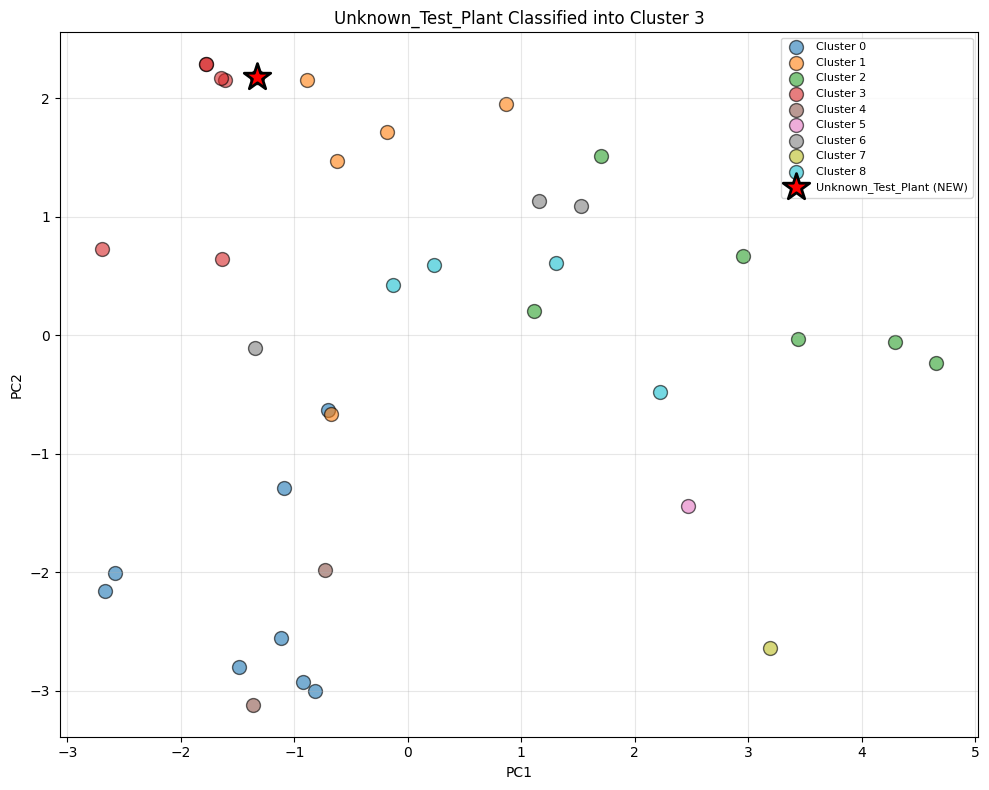

In [12]:
# Block 9: DEPLOYMENT BLOCK
# Input a new plant's phytochemical screening results and
# marker compound, and find which existing cluster it belongs to

from rdkit import Chem
from rdkit.Chem import Descriptors

print("="*70)
print("PLANT CLASSIFICATION TOOL")
print("="*70)
print("""
********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The values currently in the INPUT SECTION below are           *
*   DEMONSTRATION VALUES ONLY (based on Tulsi/Clove-like data).    *
*   They exist so this block runs successfully on first try and   *
*   shows you what a correct result looks like.                    *
*                                                                  *
*   These are NOT your real plant's data.                         *
*                                                                  *
*   TO CLASSIFY YOUR OWN ACTUAL PLANT EXTRACT:                    *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_plant_name with your plant's name              *
*   3. REPLACE each 0/1 value in new_plant_phytochemistry with    *
*      YOUR OWN qualitative screening test results                *
*      (0 = test negative/absent, 1 = test positive/present)      *
*   4. REPLACE new_plant_marker_smiles with the SMILES of your     *
*      plant's actual marker/major phytochemical compound          *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   5. Do NOT change anything below the                            *
*      "END OF INPUT SECTION" line                                 *
*   6. Then run this cell again                                    *
*                                                                  *
*   No file upload is needed for this block - all input is        *
*   typed directly into the Python variables below.                *
*                                                                  *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================
# DELETE the demonstration values and TYPE your own plant's data.
# Do not add or remove any lines - only change the values.

new_plant_name = "Unknown_Test_Plant"                    # <-- EDIT: type your plant's name in quotes

new_plant_phytochemistry = {
    'Alkaloids': 0,          # <-- EDIT: 1 if your Mayer's/Dragendorff's test was positive, else 0
    'Flavonoids': 1,         # <-- EDIT: 1 if your Shinoda test was positive, else 0
    'Tannins': 1,            # <-- EDIT: 1 if your ferric chloride test was positive, else 0
    'Saponins': 0,           # <-- EDIT: 1 if your foam test was positive, else 0
    'Terpenoids': 1,         # <-- EDIT: 1 if your Salkowski test was positive, else 0
    'Steroids': 0,           # <-- EDIT: 1 if your Salkowski test (steroid variant) was positive, else 0
    'Glycosides': 0,         # <-- EDIT: 1 if your Molisch's test was positive, else 0
    'Phenolics': 1,          # <-- EDIT: 1 if your ferric chloride phenolic test was positive, else 0
    'Anthraquinones': 0,     # <-- EDIT: 1 if your Borntrager's test was positive, else 0
    'VolatileOils': 1        # <-- EDIT: 1 if volatile/aromatic oil was detected, else 0
}

new_plant_marker_smiles = "COc1cc(CC=C)ccc1O"
# <-- EDIT: replace this entire line with YOUR compound's SMILES string
# (the demonstration value above is Eugenol - delete it and paste yours)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\n{'='*70}")
print("CONFIRMING YOUR INPUT (please check this matches what you typed)")
print(f"{'='*70}")
print(f"Plant name entered: {new_plant_name}")
print(f"Phytochemistry entered: {new_plant_phytochemistry}")
print(f"Marker SMILES entered: {new_plant_marker_smiles}")
if new_plant_name == "Unknown_Test_Plant":
    print("\n*** WARNING: You are still using the DEMONSTRATION values. ***")
    print("*** Edit the STUDENT INPUT SECTION above with your own data. ***")
print(f"{'='*70}")

mol = Chem.MolFromSmiles(new_plant_marker_smiles)
if mol is None:
    print("\nERROR: Invalid SMILES provided for marker compound")
    print("Check your SMILES string - it may contain a typo")
else:
    new_descriptors = {
        'Marker_MW': Descriptors.MolWt(mol),
        'Marker_LogP': Descriptors.MolLogP(mol),
        'Marker_HBD': Descriptors.NumHDonors(mol),
        'Marker_HBA': Descriptors.NumHAcceptors(mol),
        'Marker_TPSA': Descriptors.TPSA(mol),
        'Marker_RotBonds': Descriptors.NumRotatableBonds(mol)
    }

    print(f"\nMarker compound descriptors calculated:")
    for k, v in new_descriptors.items():
        print(f"  {k}: {v:.2f}")

    new_feature_dict = {**new_plant_phytochemistry, **new_descriptors}
    new_feature_vector = pd.DataFrame([new_feature_dict])[feature_cols]

    new_scaled = scaler.transform(new_feature_vector)

    predicted_cluster = kmeans_final.predict(new_scaled)[0]

    print(f"\n{'='*70}")
    print(f"PREDICTED CLUSTER: {predicted_cluster}")
    print(f"{'='*70}")

    similar_plants = df[df['Cluster_KMeans'] == predicted_cluster]

    print(f"\nThis plant is chemically most similar to "
          f"{len(similar_plants)} known plants:")
    print(f"  {', '.join(similar_plants['Plant'].tolist())}")

    print(f"\nShared phytochemical characteristics of this cluster:")
    for col in phyto_cols:
        cluster_pct = similar_plants[col].mean() * 100
        if cluster_pct >= 60 or cluster_pct <= 20:
            status = "commonly present" if cluster_pct >= 60 else "commonly absent"
            print(f"  {col}: {status} ({cluster_pct:.0f}% of cluster members)")

    print(f"\nTraditional uses of chemically similar plants "
          f"(for hypothesis generation):")
    for use in similar_plants['Traditional_Use'].tolist()[:5]:
        print(f"  - {use}")

    distance_to_center = np.linalg.norm(
        new_scaled - kmeans_final.cluster_centers_[predicted_cluster]
    )
    print(f"\nDistance to cluster center: {distance_to_center:.3f}")
    print("(Lower = more typical member of this cluster; "
          "higher = more borderline/atypical)")

    new_pca = pca.transform(new_scaled)
    fig, ax = plt.subplots(figsize=(10, 8))
    unique_clusters = sorted(df['Cluster_KMeans'].unique())
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    for i, cluster_id in enumerate(unique_clusters):
        mask = df['Cluster_KMeans'] == cluster_id
        ax.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                   label=f'Cluster {cluster_id}', color=colors_map[i],
                   s=100, edgecolor='black', alpha=0.6)
    ax.scatter(new_pca[0, 0], new_pca[0, 1], color='red', s=400,
               marker='*', edgecolor='black', linewidth=2,
               label=f'{new_plant_name} (NEW)', zorder=5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{new_plant_name} Classified into Cluster {predicted_cluster}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Meaning of Block 9 (updated with student input safeguards):

Purpose:
A practical chemotaxonomic classification tool — a student inputs the qualitative phytochemical screening results and marker compound SMILES for a real, uncharacterized plant extract, and the tool identifies which existing cluster of known medicinal plants it most closely resembles, along with a testable pharmacological hypothesis based on that resemblance.

What data comes IN:

Student-typed input from the clearly marked "STUDENT INPUT SECTION" — 10 phytochemical screening results (0 or 1) and one marker compound SMILES string
scaler, kmeans_final, pca, df, feature_cols, phyto_cols from all previous blocks

What happens inside — line by line:

The banner warning printed at the very top exists specifically to prevent a real mistake students commonly make with deployment blocks: running the cell once, seeing a confident-looking result, and assuming it reflects their own data — when in fact it only ran successfully because pre-filled demonstration values were sitting in the input section. This banner makes that impossible to miss.
Every line inside new_plant_phytochemistry now carries an inline comment naming the exact laboratory test that produces that value (Mayer's/Dragendorff's test for alkaloids, Shinoda test for flavonoids, ferric chloride test for tannins, foam test for saponins, Salkowski test for terpenoids and steroids, Molisch's test for glycosides, Borntrager's test for anthraquinones) — connecting the abstract 0/1 input directly to the real pharmacognosy lab procedure a student would have actually performed to obtain that value.
The explicit statement "No file upload is needed for this block" heads off a second common confusion — since some other deployment blocks in this series (and future ones) do require file uploads, this line makes clear that this specific block only needs typed values, nothing more.
mol = Chem.MolFromSmiles(new_plant_marker_smiles) — validates the student's SMILES immediately. If invalid, the block stops with a clear error rather than silently producing a meaningless result.
The confirmation echo block (CONFIRMING YOUR INPUT) is new — it prints back exactly what values the code is about to use, in plain view, before any calculation happens. The line if new_plant_name == "Unknown_Test_Plant": is an automatic safety check: since this exact string is the untouched demonstration default, if it still matches, the code knows with certainty the student has not yet edited anything, and prints a second, impossible-to-miss warning.
new_descriptors = {...} — calculates the same 6 molecular descriptors (molecular weight, LogP, hydrogen bond donors/acceptors, TPSA, rotatable bonds) from the student's marker compound, using the identical RDKit method used throughout every previous practical in this series.
new_feature_dict = {**new_plant_phytochemistry, **new_descriptors} — merges the 10 phytochemical flags and 6 descriptors into one complete 16-value profile, matching the exact structure the clustering model was trained on.
scaler.transform(new_scaled) — critically uses .transform(), never .fit_transform(), applying the exact scaling parameters (means and standard deviations) learned from the original 38 training plants in Block 2, so the new plant's profile sits on a directly comparable scale.
kmeans_final.predict(new_scaled)[0] — the actual classification: K-Means measures the distance from the new plant's scaled profile to each of the OPTIMAL_K cluster centers established during training, and assigns it to whichever center is closest.
The similar-plants listing, shared phytochemical characteristics, and traditional-use summary translate the raw predicted cluster number into genuine, interpretable pharmacognosy findings — telling the student which known, already-studied plants their new sample most resembles.
distance_to_center — measures how confidently or borderline the new plant fits within its assigned cluster; a small value means a clear, typical match, a large value suggests the plant sits between two clusters and might warrant closer chemical investigation.
The final PCA scatter plot displays all 38 known reference plants in their established positions, then adds the new plant as a prominent red star, giving an immediate visual sense of exactly where it falls relative to every previously characterized plant.

What comes OUT:
A confirmed record of exactly what the student entered, followed by a predicted cluster assignment, a list of chemically similar known plants, shared phytochemical characteristics defining that group, a distance-based confidence measure, and a 2D visualization showing precisely where the new plant sits relative to all 38 reference plants.

In [11]:
# Block 10: Save all clustering results and generate final summary

import joblib

df_export = df[['Plant', 'Scientific_Name', 'Marker_Compound',
                 'Traditional_Use', 'Cluster_KMeans',
                 'Cluster_Hierarchical', 'Cluster_DBSCAN']].copy()

df_export.to_excel('plant_clustering_results.xlsx', index=False)

joblib.dump(kmeans_final, 'plant_clustering_kmeans_model.pkl')
joblib.dump(scaler, 'plant_clustering_scaler.pkl')
joblib.dump(pca, 'plant_clustering_pca.pkl')

import json
model_info = {
    'model_type': 'K-Means Clustering',
    'n_clusters': int(OPTIMAL_K),
    'silhouette_score': float(final_silhouette),
    'n_plants_trained': len(df),
    'feature_columns': feature_cols,
    'phytochemical_features': phyto_cols,
    'descriptor_features': descriptor_cols,
    'notes': (
        'Clusters 38 medicinal plants based on qualitative '
        'phytochemical screening (10 classes) and marker compound '
        'molecular descriptors (6 properties). Use Block 9 '
        'deployment tool to classify new plants.'
    )
}
with open('plant_clustering_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

from google.colab import files
files.download('plant_clustering_results.xlsx')
files.download('plant_clustering_kmeans_model.pkl')
files.download('plant_clustering_scaler.pkl')
files.download('plant_clustering_pca.pkl')
files.download('plant_clustering_model_info.json')

print("="*60)
print("PRACTICAL COMPLETE — FINAL SUMMARY")
print("="*60)
print(f"Total plants analyzed: {len(df)}")
print(f"Features used for clustering: {len(feature_cols)}")
print(f"  ({len(phyto_cols)} phytochemical + {len(descriptor_cols)} descriptor)")
print(f"\nOptimal number of clusters (data-driven): {OPTIMAL_K}")
print(f"K-Means silhouette score: {final_silhouette:.3f}")
print(f"Hierarchical silhouette score: {hier_silhouette:.3f}")
print(f"DBSCAN clusters found independently: {n_clusters_dbscan}")
print(f"Agreement (K-Means vs Hierarchical, ARI): {ari:.3f}")
print(f"\nFiles saved:")
print("  1. plant_clustering_results.xlsx - all cluster assignments")
print("  2. plant_clustering_kmeans_model.pkl - trained model")
print("  3. plant_clustering_scaler.pkl - feature scaler")
print("  4. plant_clustering_pca.pkl - PCA transformer")
print("  5. plant_clustering_model_info.json - documentation")
print("\nUpload all files to GitHub models/ folder")
print("="*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PRACTICAL COMPLETE — FINAL SUMMARY
Total plants analyzed: 38
Features used for clustering: 16
  (10 phytochemical + 6 descriptor)

Optimal number of clusters (data-driven): 9
K-Means silhouette score: 0.267
Hierarchical silhouette score: 0.277
DBSCAN clusters found independently: 1
Agreement (K-Means vs Hierarchical, ARI): 0.695

Files saved:
  1. plant_clustering_results.xlsx - all cluster assignments
  2. plant_clustering_kmeans_model.pkl - trained model
  3. plant_clustering_scaler.pkl - feature scaler
  4. plant_clustering_pca.pkl - PCA transformer
  5. plant_clustering_model_info.json - documentation

Upload all files to GitHub models/ folder


Meaning of Block 10:

Purpose: Save the complete clustering results and all three fitted transformation objects (scaler, PCA, K-Means model) needed to classify future new plants, plus a final consolidated summary of the entire practical's findings.

What data comes IN: df, kmeans_final, scaler, pca, OPTIMAL_K, final_silhouette, hier_silhouette, n_clusters_dbscan, ari from all previous blocks.

Why three separate model files are saved (not just one):
Unlike a single supervised model, this deployment pipeline requires three components working together in exact sequence: the scaler (to standardize a new plant's raw features), the kmeans_final model (to assign the cluster), and pca (to visualize the new plant's position). All three must be saved and reloaded together — using the K-Means model without the matching scaler would produce meaningless results, since the model expects standardized input.

What comes OUT: Five files — the complete results spreadsheet, three fitted model components, and one JSON documentation file — together forming a fully reusable, deployable plant classification system.